# Backtester Experimentation

An interactive walkthrough of the engine: load data, run strategies, inspect results.
Run the cells top to bottom.

In [2]:
# make the project root importable (this notebook lives in notebooks/)
import sys, os
sys.path.insert(0, os.path.abspath(".."))

%matplotlib inline
import pandas as pd

from config import Config
from data.downloader import download_data
from data.loader import load_data
from strategies.buy_and_hold import BuyAndHoldStrategy
from strategies.ma_crossover import MACrossoverStrategy
from analytics.plot import plot_equity_curve
import main

## 1. Configure and load data

All run settings live in `Config`. Data is downloaded once and cached to CSV; re-runs are instant.

In [3]:
cfg = Config()  # e.g. Config(tickers=("AAPL", "MSFT"), initial_capital=50_000)

data = {t: load_data(download_data(t, cfg.start, cfg.end)) for t in cfg.tickers}
data[cfg.tickers[0]].head()

,close,high,low,open,volume
Price,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630623,72.389242,71.406651,71.563190,146322800
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200


## 2. Run the strategies

Each call wires a fresh engine (data handler, portfolio, broker) and runs one strategy across the universe.

In [4]:
bh = main.run_backtest(data, BuyAndHoldStrategy, cfg)
ma = main.run_backtest(data, MACrossoverStrategy, cfg)

main.report("Buy & Hold", bh)
main.report("MA Crossover", ma, show_trades=True)


Buy & Hold
  Total return:   77.41%
  CAGR:           21.06%
  Max drawdown:   -31.11%
  Ann. vol:       36.63%
  Sharpe ratio:   0.71
  Time in market: 100%
  Realized PnL:   0.00
  Win rate:       N/A (0 trades)

MA Crossover
  Total return:   45.12%
  CAGR:           13.22%
  Max drawdown:   -25.14%
  Ann. vol:       22.70%
  Sharpe ratio:   0.66
  Time in market: 55%
  Realized PnL:   45,124.81
  Win rate:       44% (9 trades)
  Avg win/loss:   23,927.36 / -10,116.93
  Trades:
    symbol      shares     entry      exit         pnl
    AAPL          1407     69.21    110.43    57853.87
    AAPL          1365    115.14    120.36     6965.11
    AAPL          1254    131.58    123.19   -10686.76
    AAPL          1171    131.59    138.32     7712.94
    AAPL          1096    148.72    170.03    23177.52
    AAPL          1078    168.97    156.22   -13916.53
    AAPL          1138    151.69    150.51    -1505.06
    AAPL          1163    145.88    138.97    -8193.08
    AAPL          

## 3. Compare equity curves

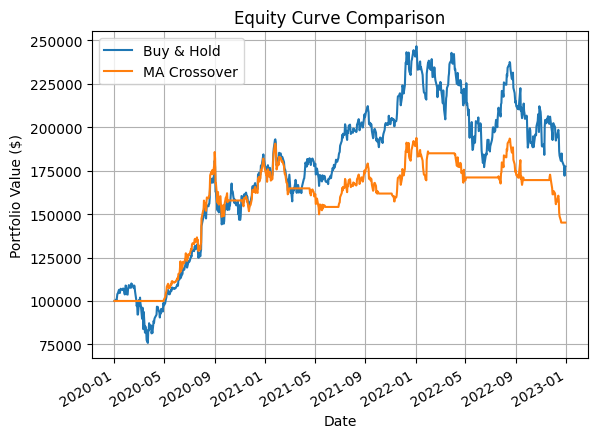

In [5]:
plot_equity_curve({
    "Buy & Hold": bh.equity_curve,
    "MA Crossover": ma.equity_curve,
})

## 4. Inspect the trade log

Every closed round-trip as a row — sort, filter, or aggregate it like any dataframe.

In [6]:
trades = pd.DataFrame([vars(t) for t in ma.trades])
trades

,symbol,shares,entry_price,exit_price,pnl,exit_date
0,AAPL,1407,69.205421,110.434457,57853.872236,2020-10-05
1,AAPL,1365,115.137792,120.360794,6965.105364,2021-03-01
2,AAPL,1254,131.584960,123.186012,-10686.755306,2021-05-27
3,AAPL,1171,131.593716,138.318663,7712.941816,2021-10-04
4,AAPL,1096,148.716146,170.033553,23177.520694,2022-02-01
5,AAPL,1078,168.973387,156.220025,-13916.530165,2022-05-04
6,AAPL,1138,151.686833,150.514802,-1505.057488,2022-09-20
7,AAPL,1163,145.876459,138.970648,-8193.081492,2022-11-30
8,AAPL,1105,143.739442,129.132641,-16283.206876,2022-12-20


In [7]:
# quick win/loss breakdown
if not trades.empty:
    print("winners:", (trades.pnl > 0).sum(), "  losers:", (trades.pnl < 0).sum())
    print("best trade: ", round(trades.pnl.max(), 2))
    print("worst trade:", round(trades.pnl.min(), 2))

winners: 4   losers: 5
best trade:  57853.87
worst trade: -16283.21
